In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\Javier\AppData\Roaming\Python\Python313\site-packages\seaborn\_statistics.py:32: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.3.4)
  from scipy.stats import gaussian_kde


In [ ]:
#Link del dataset
#https://www.kaggle.com/datasets/shivamb/netflix-shows?select=netflix_titles.csv

In [2]:
#cargar el archivo
df = pd.read_csv('netflix_titles.csv')

In [5]:
print(df.shape)
print(df.head())

(8807, 12)
  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24, 2

In [6]:
print(df.dtypes)

show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object


In [8]:
print(df.isnull().mean().sort_values(ascending=False))

director        0.299080
country         0.094357
cast            0.093675
date_added      0.001135
rating          0.000454
duration        0.000341
show_id         0.000000
type            0.000000
title           0.000000
release_year    0.000000
listed_in       0.000000
description     0.000000
dtype: float64


In [9]:
#tratamiento de valores nulos
df['country'] = df['country'].fillna('Unknown')

In [ ]:
#nuevas variables de tiempo
df['date_added'] = pd.to_datetime(df['date_added'].str.strip())
df['year_added'] = df['date_added'].dt.year

In [18]:
print(df.head())

  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...        Unknown   
3                                                NaN        Unknown   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

  date_added  release_year rating   duration  \
0 2021-09-25          2020  PG-13     90 min   
1 2021-09-24          2021  TV-MA  2 Seasons   
2 2021-09-24          2021  TV-MA   1 Season   
3 2021-0

In [19]:
print(df.dtypes)

show_id                 object
type                    object
title                   object
director                object
cast                    object
country                 object
date_added      datetime64[ns]
release_year             int64
rating                  object
duration                object
listed_in               object
description             object
year_added             float64
dtype: object


C:\Users\Javier\AppData\Local\Temp\ipykernel_3020\2128077955.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=type_counts.index,y=type_counts.values, palette='viridis')


<function matplotlib.pyplot.show(close=None, block=None)>

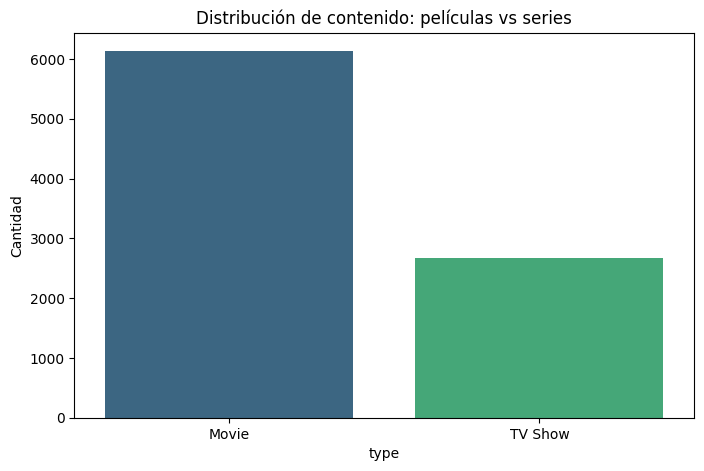

In [21]:
#comparativa películas vs series
type_counts = df['type'].value_counts()

plt.figure(figsize=(8,5))
sns.barplot(x=type_counts.index,y=type_counts.values, palette='viridis')
plt.title('Distribución de contenido: películas vs series')
plt.ylabel('Cantidad')
plt.show

In [23]:
#evolución histórica de los estrenos

evolucion = df['year_added'].value_counts().sort_index(ascending=True)
print(evolucion)

year_added
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      11
2014.0      24
2015.0      82
2016.0     429
2017.0    1188
2018.0    1649
2019.0    2016
2020.0    1879
2021.0    1498
Name: count, dtype: int64


<function matplotlib.pyplot.show(close=None, block=None)>

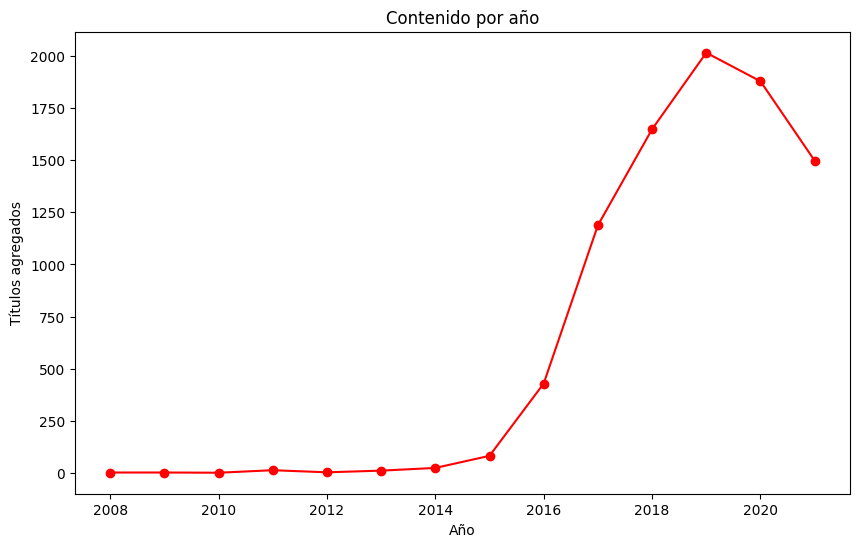

In [25]:
plt.figure(figsize=(10,6))
plt.plot(evolucion.index, evolucion.values, marker='o', linestyle='-', color='red')
plt.title('Contenido por año')
plt.xlabel('Año')
plt.ylabel('Títulos agregados')
#plt.grid()
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

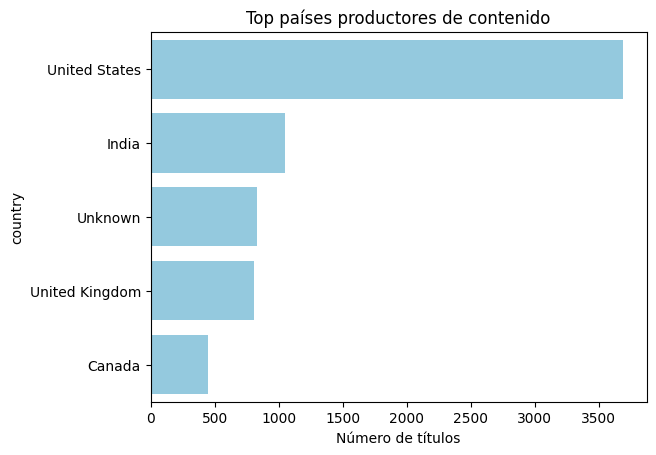

In [27]:
#países con más producciones
top_countries = df['country'].str.split(', ').explode().value_counts().head()

plt.Figure(figsize=(8,5))
sns.barplot(y=top_countries.index, x=top_countries.values, color='skyblue')
plt.title('Top países productores de contenido')
plt.xlabel('Número de títulos')
plt.show